        Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                0.0     1.0       1.0        1.0  24.0     0.0     0.0   
...              ...     ...       ...        ...   ...     ...     ...   
253675           0.0     1.0       1.0        1.0  45.0     0.0     0.0   
253676           2.0     1.0       1.0        1.0  18.0     0.0     0.0   
253677           0.0     0.0       0.0        1.0  28.0     0.0     0.0   
253678           0.0     1.0       0.0        1.0  23.0     0.0     0.0   
253679           2.0     1.0       1.0        1.0  25.0     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                        

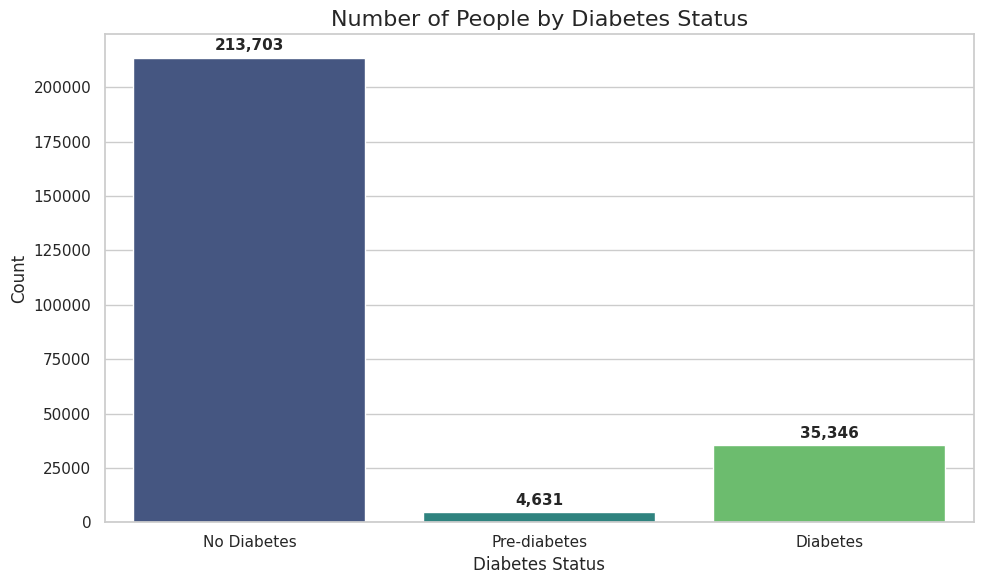

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
###########################what Data Contain #################################################
df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
print(df)
diabetes_map = {0.0: 'No Diabetes', 1.0: 'Pre-diabetes', 2.0: 'Diabetes'}
df['Diabetes_Status'] = df['Diabetes_012'].map(diabetes_map)
status_counts = df['Diabetes_Status'].value_counts().reindex(['No Diabetes', 'Pre-diabetes', 'Diabetes'])
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar chart
plot = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,  # Assign x to hue
    palette='viridis',
    legend=False              # Hide the extra legend box
)

# Add labels and title
plt.title('Number of People by Diabetes Status', fontsize=16)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add the count numbers on top of each bar for better readability
for i, count in enumerate(status_counts.values):
    plt.text(i, count + 2000, f'{int(count):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('diabetes_bar_chart.png')
plt.show()

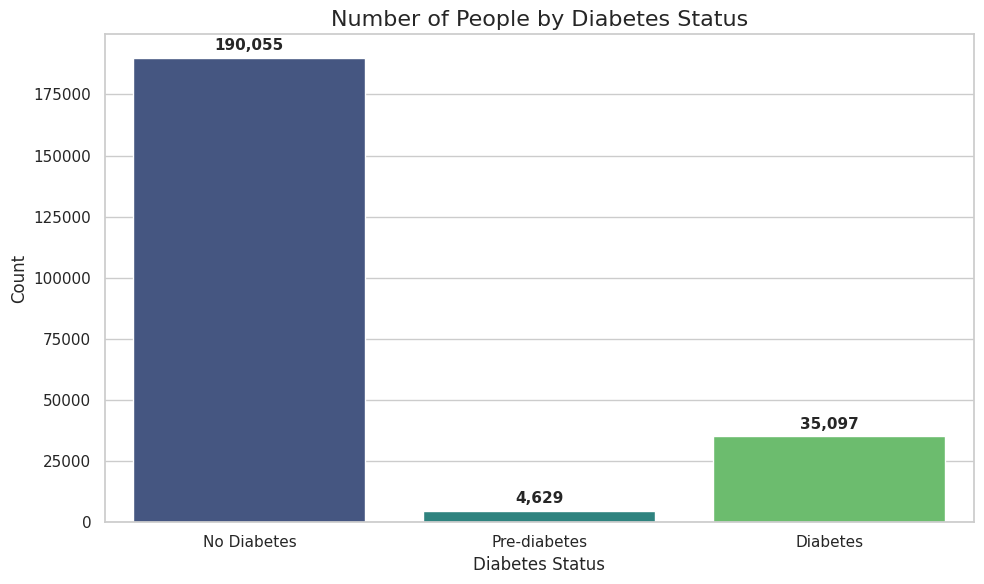

In [4]:
#cleaning Data

df.dropna(inplace= True)
df.drop_duplicates(inplace = True)
status_counts = df['Diabetes_Status'].value_counts().reindex(['No Diabetes', 'Pre-diabetes', 'Diabetes'])
## Data does not contain empty cell
##############################plot after remove duplicates####################################
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the bar chart
plot = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Number of People by Diabetes Status', fontsize=16)
plt.xlabel('Diabetes Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

for i, count in enumerate(status_counts.values):
    plt.text(i, count + 2000, f'{int(count):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('diabetes_after_re_dublicates.png')
plt.show()

## Splitting Data

In [5]:
x = df.drop(columns=['Diabetes_012','Diabetes_Status'])
y = df['Diabetes_012']
df=df.drop(columns=['Diabetes_Status'])
X_train_val, X_test, y_train_val, y_test = train_test_split(
    x, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # Fixed seed for reproducibility
    stratify=y         # Maintain class proportions
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.125,     # 12.5% of the 80% is 10% of the original
    random_state=42,
    stratify=y_train_val
)

def print_distribution(y_set, name):
    counts = y_set.value_counts().sort_index()
    percentages = y_set.value_counts(normalize=True).sort_index() * 100
    labels = {0.0: 'No Diabetes', 1.0: 'Pre-diabetes', 2.0: 'Diabetes'}

    print(f"--- {name} Set ---")
    for val in [0.0, 1.0, 2.0]:
        print(f"{labels[val]}: {int(counts[val])} samples ({percentages[val]:.2f}%)")
    print("-" * 30)

print_distribution(y_train, "Training (70%)")
print_distribution(y_val, "Validation (10%)")
print_distribution(y_test, "Testing (20%)")


--- Training (70%) Set ---
No Diabetes: 133038 samples (82.71%)
Pre-diabetes: 3240 samples (2.01%)
Diabetes: 24568 samples (15.27%)
------------------------------
--- Validation (10%) Set ---
No Diabetes: 19005 samples (82.71%)
Pre-diabetes: 463 samples (2.01%)
Diabetes: 3510 samples (15.28%)
------------------------------
--- Testing (20%) Set ---
No Diabetes: 38012 samples (82.71%)
Pre-diabetes: 926 samples (2.01%)
Diabetes: 7019 samples (15.27%)
------------------------------


## Feature Preprocessing

In [6]:
### scaling the data
scaler = StandardScaler()

features_to_scale = [
    "BMI",
    "MentHlth",
    "PhysHlth",
    "GenHlth",
    "Age",
    "Education",
    "Income"
]

X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_val[features_to_scale] = scaler.transform(X_val[features_to_scale])
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])
print(X_train)
print(X_val)

        HighBP  HighChol  CholCheck       BMI  Smoker  Stroke  \
107646     0.0       1.0        1.0 -0.837749     0.0     0.0   
183234     1.0       1.0        1.0  0.779355     1.0     0.0   
133308     1.0       1.0        1.0  1.367392     0.0     0.0   
116763     1.0       1.0        1.0 -0.396720     1.0     0.0   
98863      0.0       0.0        1.0  1.220383     1.0     0.0   
...        ...       ...        ...       ...     ...     ...   
29652      0.0       0.0        1.0  1.073373     1.0     0.0   
7644       0.0       1.0        1.0 -0.543730     0.0     0.0   
191656     0.0       1.0        1.0 -0.249711     1.0     0.0   
242217     1.0       1.0        1.0 -0.837749     0.0     0.0   
196847     0.0       0.0        1.0 -0.837749     0.0     0.0   

        HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  ...  \
107646                   0.0           1.0     1.0      1.0  ...   
183234                   0.0           1.0     1.0      1.0  ...   
133308         

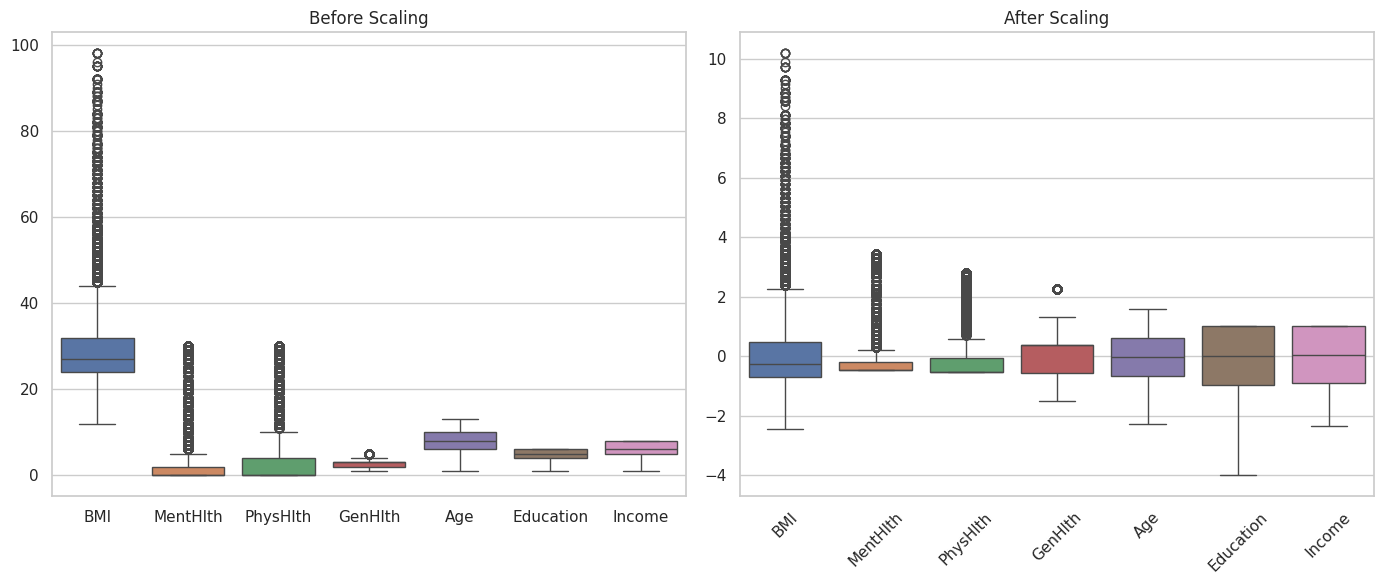

In [7]:
### plot before and after scaling ###########
fig, ax = plt.subplots(1,2, figsize=(14,6))

sns.boxplot(data=df[features_to_scale], ax=ax[0])
ax[0].set_title("Before Scaling")

sns.boxplot(data=X_train[features_to_scale], ax=ax[1])
ax[1].set_title("After Scaling")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

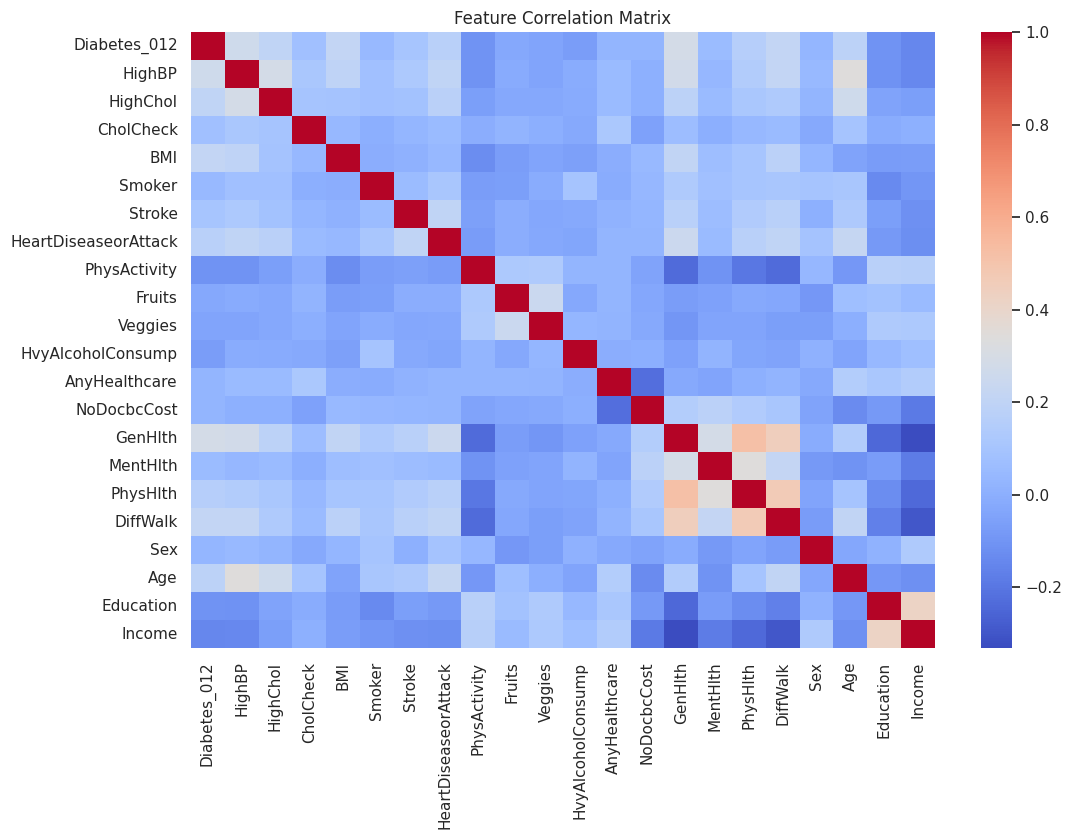

Diabetes_012            1.000000
GenHlth                 0.284881
HighBP                  0.261976
BMI                     0.212027
DiffWalk                0.210638
HighChol                0.203327
Age                     0.184642
HeartDiseaseorAttack    0.170816
PhysHlth                0.160485
Stroke                  0.100276
CholCheck               0.075701
MentHlth                0.057698
Smoker                  0.046774
Sex                     0.032243
AnyHealthcare           0.024911
NoDocbcCost             0.023568
Fruits                 -0.025462
Veggies                -0.043446
HvyAlcoholConsump      -0.067164
PhysActivity           -0.103408
Education              -0.107742
Income                 -0.147102
Name: Diabetes_012, dtype: float64


In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

correlation_matrix = df.corr()
diabetes_correlation = correlation_matrix["Diabetes_012"]
sorted_correlation = diabetes_correlation.sort_values(ascending=False)
print(sorted_correlation)


## Feature Selection

In [9]:
selector = SelectKBest(score_func=chi2, k=10)
X_new = selector.fit_transform(x, y)
scores = selector.scores_

feature_score_pairs = list(zip(x.columns, scores))


feature_score_pairs.sort(key=lambda x: x[1], reverse=True)


print(f"{'Feature':<22} | {'Chi-Squared Score'}")
print("-" * 40)
for feature, score in feature_score_pairs:
    print(f"{feature:<22} | {score:.4f}")

Feature                | Chi-Squared Score
----------------------------------------
PhysHlth               | 103705.8134
BMI                    | 16667.0062
MentHlth               | 13499.0566
Age                    | 9400.4089
HighBP                 | 8633.5628
DiffWalk               | 8310.2805
GenHlth                | 8142.6027
HeartDiseaseorAttack   | 6015.6619
HighChol               | 5381.9855
Income                 | 3748.2547
Stroke                 | 2212.0608
HvyAlcoholConsump      | 973.6770
PhysActivity           | 656.1876
Education              | 537.0689
Smoker                 | 268.9241
NoDocbcCost            | 163.1384
Sex                    | 136.9989
Veggies                | 89.5549
Fruits                 | 57.6667
CholCheck              | 54.1557
AnyHealthcare          | 7.8835


HighBP 0.03772163049674929
HighChol 0.025379360768291295
CholCheck 0.0037781647267739193
BMI 0.18301539066026593
Smoker 0.03442158920867787
Stroke 0.012125988267375059
HeartDiseaseorAttack 0.01647500497937947
PhysActivity 0.027542579256315643
Fruits 0.03426842383776529
Veggies 0.027650043537679345
HvyAlcoholConsump 0.007662100326167946
AnyHealthcare 0.009046509305220125
NoDocbcCost 0.015659682472051562
GenHlth 0.06580937907597705
MentHlth 0.06492627541798834
PhysHlth 0.08580948482927603
DiffWalk 0.022584258190254444
Sex 0.027408934228741882
Age 0.1232421387479061
Education 0.0735394021172619
Income 0.10193365954988151


<Axes: xlabel='Feature'>

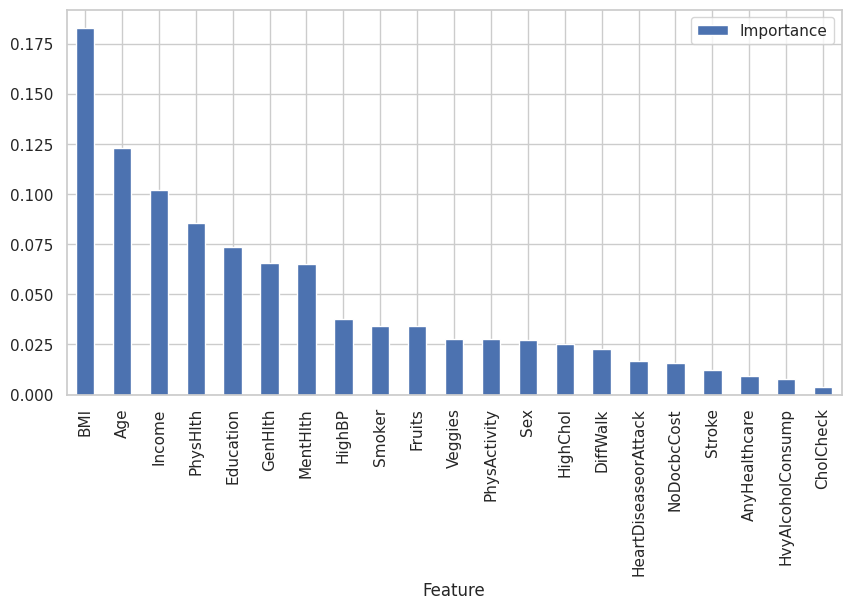

In [10]:
model = RandomForestClassifier()
model.fit(x, y)

importance = model.feature_importances_

for feature, score in zip(x.columns, importance):
    print(feature, score)

importance_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
})

importance_df.sort_values("Importance", ascending=False).plot.bar(
    x="Feature", y="Importance", figsize=(10,5)
)

In [11]:

# List of alpha values to try
alphas = [0.001, 0.01, 0.1, 1]

best_alpha = None
best_score = -float('inf')

# Hyperparameter tuning using validation set
for alpha in alphas:
    model = Lasso(alpha=alpha)
    model.fit(X_train, y_train)  # use only training set
    score = model.score(X_val, y_val)  # evaluate on validation set
    if score > best_score:
        best_score = score
        best_alpha = alpha

print("Best alpha:", best_alpha)

# Train final Lasso with best alpha on the training set
final_model = Lasso(alpha=best_alpha)
final_model.fit(X_train, y_train)

# Create a DataFrame with feature weights
weights_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': final_model.coef_
})

weights_df['Magnitude'] = weights_df['Weight'].abs()
weights_df = weights_df.sort_values(by='Magnitude', ascending=False)

print(weights_df[['Feature', 'Weight']])

Best alpha: 0.001
                 Feature    Weight
0                 HighBP  0.160669
1               HighChol  0.129010
6   HeartDiseaseorAttack  0.112157
13               GenHlth  0.109524
3                    BMI  0.098206
10     HvyAlcoholConsump -0.091847
2              CholCheck  0.070230
16              DiffWalk  0.069522
18                   Age  0.056391
5                 Stroke  0.049336
17                   Sex  0.038711
20                Income -0.026111
11         AnyHealthcare  0.014147
4                 Smoker -0.010089
7           PhysActivity -0.007717
14              MentHlth -0.006503
19             Education -0.004713
12           NoDocbcCost -0.001957
8                 Fruits -0.000155
9                Veggies -0.000000
15              PhysHlth -0.000000


In [12]:
selected_features = weights_df[weights_df['Magnitude'] > 0.01]['Feature']

X_train = X_train[selected_features]
X_val = X_val[selected_features]
X_test = X_test[selected_features]

print("Selected Features:", list(selected_features))

Selected Features: ['HighBP', 'HighChol', 'HeartDiseaseorAttack', 'GenHlth', 'BMI', 'HvyAlcoholConsump', 'CholCheck', 'DiffWalk', 'Age', 'Stroke', 'Sex', 'Income', 'AnyHealthcare', 'Smoker']


## Handling Class Imbalance

#### Random Oversampling


In [13]:
## Random oversampling
ros = RandomOverSampler(random_state=42)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Before oversampling:")
print(y_train.value_counts())
print("\nAfter oversampling:")
print(y_train_over.value_counts())

Before oversampling:
Diabetes_012
0.0    133038
2.0     24568
1.0      3240
Name: count, dtype: int64

After oversampling:
Diabetes_012
0.0    133038
2.0    133038
1.0    133038
Name: count, dtype: int64


#### SMOTE

In [14]:
# Smote sampling
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Diabetes_012
0.0    133038
2.0     24568
1.0      3240
Name: count, dtype: int64

After SMOTE:
Diabetes_012
0.0    133038
2.0    133038
1.0    133038
Name: count, dtype: int64


#### Random Undersampling

In [15]:

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Before undersampling:")
print(y_train.value_counts())

print("\nAfter undersampling:")
print(y_train_under.value_counts())

Before undersampling:
Diabetes_012
0.0    133038
2.0     24568
1.0      3240
Name: count, dtype: int64

After undersampling:
Diabetes_012
0.0    3240
1.0    3240
2.0    3240
Name: count, dtype: int64


<h1>Softmax Regression</h1>

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay
from imblearn.combine import SMOTEENN
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

C_values = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1e3, 1e4]

def tune_thresholds(model, X_val, y_val, classes):
    proba = model.predict_proba(X_val)        
    best_f1, best_thr = 0.0, np.full(len(classes), 0.5)
    grid = np.arange(0.1, 0.91, 0.1)
    for t0 in grid:
        for t1 in grid:
            for t2 in grid:
                thr = np.array([t0, t1, t2])
                adjusted = proba - thr
                y_hat = classes[np.argmax(adjusted, axis=1)]
                f1 = f1_score(y_val, y_hat, average='macro')
                if f1 > best_f1:
                    best_f1, best_thr = f1, thr
    return best_thr


def predict_with_thresholds(model, X, thresholds):
    """Apply per-class thresholds to model probabilities."""
    proba = model.predict_proba(X)
    adjusted = proba - thresholds
    return model.classes_[np.argmax(adjusted, axis=1)]


def tune_and_evaluate_softmax(X_tr, y_tr, label,
                              class_weight='balanced',               
                              use_threshold_tuning=False,
                       ): 
    best_C, best_val_f1 = None, 0
    for C in C_values:
        m = LogisticRegression(
            solver='lbfgs',
            C=C,
            max_iter=5000,
            random_state=42,
            class_weight=class_weight
        )
        m.fit(X_tr, y_tr)

        if use_threshold_tuning:
            thr = tune_thresholds(m, X_val, y_val, m.classes_)
            val_pred = predict_with_thresholds(m, X_val, thr)
        else:
            val_pred = m.predict(X_val)

        val_f1 = f1_score(y_val, val_pred, average='macro')
        if val_f1 > best_val_f1:
            best_val_f1, best_C = val_f1, C


    final = LogisticRegression(
        solver='lbfgs',
        C=best_C,
        max_iter=5000,
        random_state=42,
        class_weight=class_weight
    )
    final.fit(X_tr, y_tr)

    if use_threshold_tuning:
        best_thr = tune_thresholds(final, X_val, y_val, final.classes_)
        y_pred = predict_with_thresholds(final, X_test, best_thr)
    else:
        best_thr = None
        y_pred = final.predict(X_test)

    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {label}')
    print(f'{sep}')
    print(f'Best C             : {best_C}')
    print(f'Threshold tuning   : {use_threshold_tuning}')
    if best_thr is not None:
        print(f'Best thresholds    : {best_thr.round(2)}')
    print(f'Val  Macro F1      : {best_val_f1:.4f}')
    print(f'Test Accuracy      : {accuracy_score(y_test, y_pred):.4f}')
    print(f'Test Macro F1      : {f1_score(y_test, y_pred, average="macro"):.4f}')
    print(classification_report(y_test, y_pred,
          target_names=['No Diabetes', 'Pre-diabetes', 'Diabetes']))

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No Diabetes', 'Pre-diabetes', 'Diabetes'],
        cmap='Blues'
    )
    plt.title(f'Confusion Matrix: {label}')
    plt.tight_layout()
    plt.show()

    return {
        'Strategy'        : label,
        'Best C'          : best_C,
        'Thr Tuning'      : use_threshold_tuning,
        'Val Macro F1'    : round(best_val_f1, 4),
        'Accuracy'        : round(accuracy_score(y_test, y_pred), 4),
        'Macro F1'        : round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 No-Diabetes'  : round(f1_score(y_test, y_pred, average=None)[0], 4),
        'F1 Pre-diabetes' : round(f1_score(y_test, y_pred, average=None)[1], 4),
        'F1 Diabetes'     : round(f1_score(y_test, y_pred, average=None)[2], 4),
    }

results = []


<h2>Comparing Softmax on different Data Balancing techniques</h2>


  1. Baseline (No Balancing)
Best C             : 10
Threshold tuning   : False
Val  Macro F1      : 0.3879
Test Accuracy      : 0.8331
Test Macro F1      : 0.3886
              precision    recall  f1-score   support

 No Diabetes       0.85      0.98      0.91     38012
Pre-diabetes       0.00      0.00      0.00       926
    Diabetes       0.55      0.17      0.26      7019

    accuracy                           0.83     45957
   macro avg       0.46      0.38      0.39     45957
weighted avg       0.78      0.83      0.79     45957



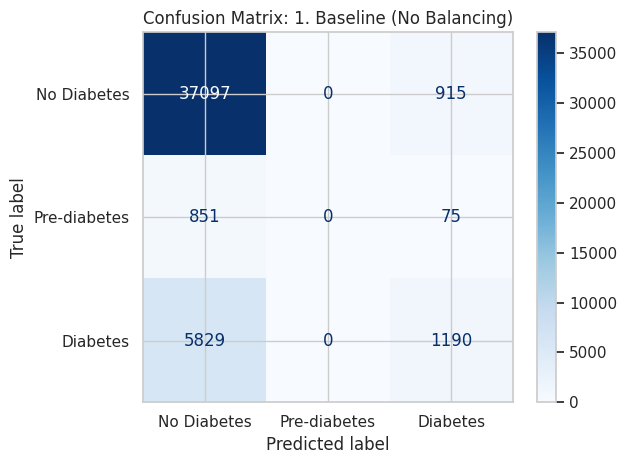


  2. Random Oversampling
Best C             : 0.001
Threshold tuning   : False
Val  Macro F1      : 0.4248
Test Accuracy      : 0.6340
Test Macro F1      : 0.4267
              precision    recall  f1-score   support

 No Diabetes       0.94      0.65      0.77     38012
Pre-diabetes       0.03      0.28      0.06       926
    Diabetes       0.37      0.60      0.45      7019

    accuracy                           0.63     45957
   macro avg       0.45      0.51      0.43     45957
weighted avg       0.84      0.63      0.71     45957



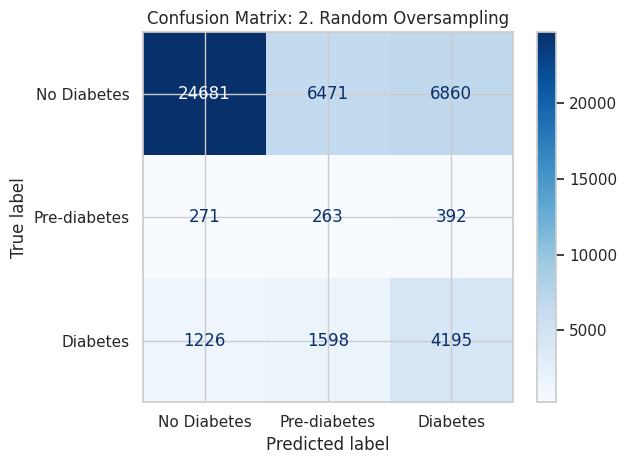


  3. SMOTE
Best C             : 0.0001
Threshold tuning   : False
Val  Macro F1      : 0.4233
Test Accuracy      : 0.6384
Test Macro F1      : 0.4276
              precision    recall  f1-score   support

 No Diabetes       0.94      0.66      0.77     38012
Pre-diabetes       0.03      0.28      0.06       926
    Diabetes       0.37      0.59      0.45      7019

    accuracy                           0.64     45957
   macro avg       0.45      0.51      0.43     45957
weighted avg       0.84      0.64      0.71     45957



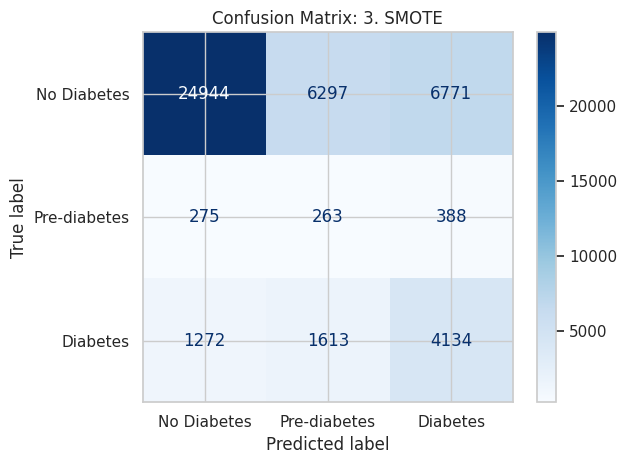


  4. Random Undersampling
Best C             : 0.0001
Threshold tuning   : False
Val  Macro F1      : 0.4292
Test Accuracy      : 0.6893
Test Macro F1      : 0.4323
              precision    recall  f1-score   support

 No Diabetes       0.93      0.71      0.80     38012
Pre-diabetes       0.03      0.10      0.04       926
    Diabetes       0.34      0.65      0.45      7019

    accuracy                           0.69     45957
   macro avg       0.43      0.49      0.43     45957
weighted avg       0.82      0.69      0.73     45957



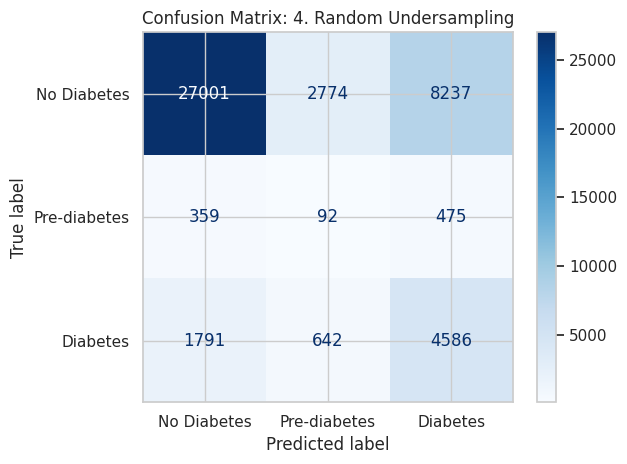

After SMOTEENN:
Diabetes_012
1.0    114688
2.0     85189
0.0     83512
Name: count, dtype: int64

  5. SMOTEENN
Best C             : 0.0001
Threshold tuning   : False
Val  Macro F1      : 0.4102
Test Accuracy      : 0.5918
Test Macro F1      : 0.4143
              precision    recall  f1-score   support

 No Diabetes       0.95      0.61      0.74     38012
Pre-diabetes       0.03      0.38      0.05       926
    Diabetes       0.38      0.54      0.45      7019

    accuracy                           0.59     45957
   macro avg       0.45      0.51      0.41     45957
weighted avg       0.84      0.59      0.68     45957



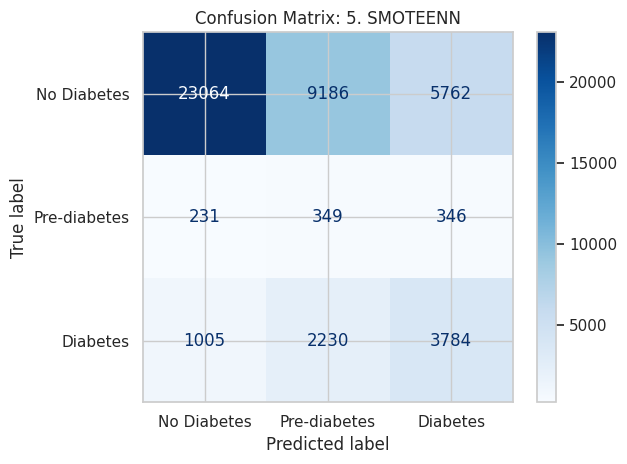


  6. Class Weights (balanced)
Best C             : 0.0001
Threshold tuning   : False
Val  Macro F1      : 0.4260
Test Accuracy      : 0.6501
Test Macro F1      : 0.4310
              precision    recall  f1-score   support

 No Diabetes       0.94      0.67      0.78     38012
Pre-diabetes       0.03      0.26      0.06       926
    Diabetes       0.36      0.60      0.45      7019

    accuracy                           0.65     45957
   macro avg       0.45      0.51      0.43     45957
weighted avg       0.83      0.65      0.72     45957



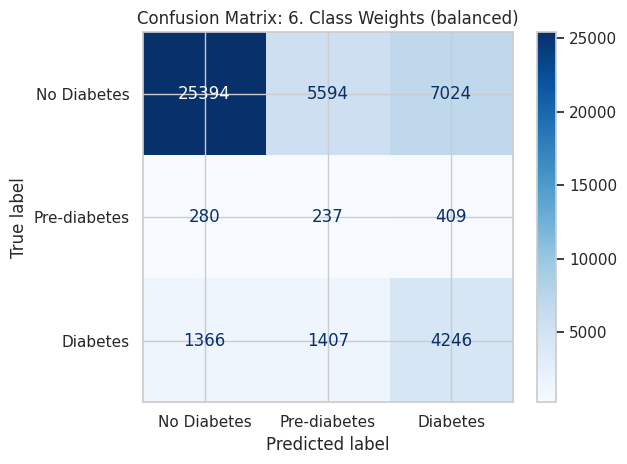


  7. Threshold Tuning
Best C             : 0.001
Threshold tuning   : True
Best thresholds    : [0.1 0.3 0.3]
Val  Macro F1      : 0.4542
Test Accuracy      : 0.7783
Test Macro F1      : 0.4602
              precision    recall  f1-score   support

 No Diabetes       0.90      0.84      0.87     38012
Pre-diabetes       0.04      0.07      0.05       926
    Diabetes       0.41      0.51      0.45      7019

    accuracy                           0.78     45957
   macro avg       0.45      0.48      0.46     45957
weighted avg       0.81      0.78      0.79     45957



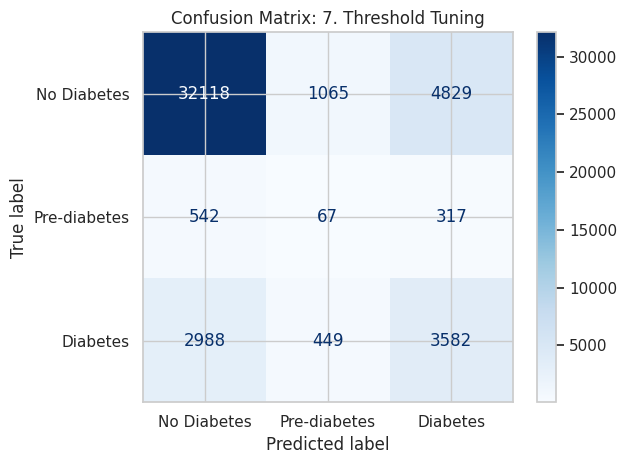

In [17]:
from imblearn.combine import SMOTEENN
res = tune_and_evaluate_softmax(X_train, y_train,
                        label='1. Baseline (No Balancing)',
                        class_weight=None)
results.append(res)
res = tune_and_evaluate_softmax(X_train_over, y_train_over,
                        label='2. Random Oversampling')
results.append(res)
res = tune_and_evaluate_softmax(X_train_smote, y_train_smote,
                        label='3. SMOTE')
results.append(res)
res = tune_and_evaluate_softmax(X_train_under, y_train_under,
                        label='4. Random Undersampling')
results.append(res)

smoteenn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train, y_train)
print('After SMOTEENN:')
print(pd.Series(y_train_smoteenn).value_counts())

res = tune_and_evaluate_softmax(X_train_smoteenn, y_train_smoteenn,
                        label='5. SMOTEENN')
results.append(res)
res = tune_and_evaluate_softmax(X_train, y_train,
                        label='6. Class Weights (balanced)',
                        class_weight='balanced')
results.append(res)

res = tune_and_evaluate_softmax(X_train, y_train,
                        label='7. Threshold Tuning',
                        class_weight='balanced',
                        use_threshold_tuning=True)
results.append(res)





COMPARISON TABLE (sorted by Macro F1)
                   Strategy  Best C  Thr Tuning  Val Macro F1  Accuracy  Macro F1  F1 No-Diabetes  F1 Pre-diabetes  F1 Diabetes
        7. Threshold Tuning  0.0010        True        0.4542    0.7783    0.4602          0.8721           0.0535       0.4549
    4. Random Undersampling  0.0001       False        0.4292    0.6893    0.4323          0.8040           0.0415       0.4514
6. Class Weights (balanced)  0.0001       False        0.4260    0.6501    0.4310          0.7807           0.0581       0.4542
                   3. SMOTE  0.0001       False        0.4233    0.6384    0.4276          0.7734           0.0578       0.4515
     2. Random Oversampling  0.0010       False        0.4248    0.6340    0.4267          0.7690           0.0568       0.4543
                5. SMOTEENN  0.0001       False        0.4102    0.5918    0.4143          0.7403           0.0550       0.4475
 1. Baseline (No Balancing) 10.0000       False        0.3879    

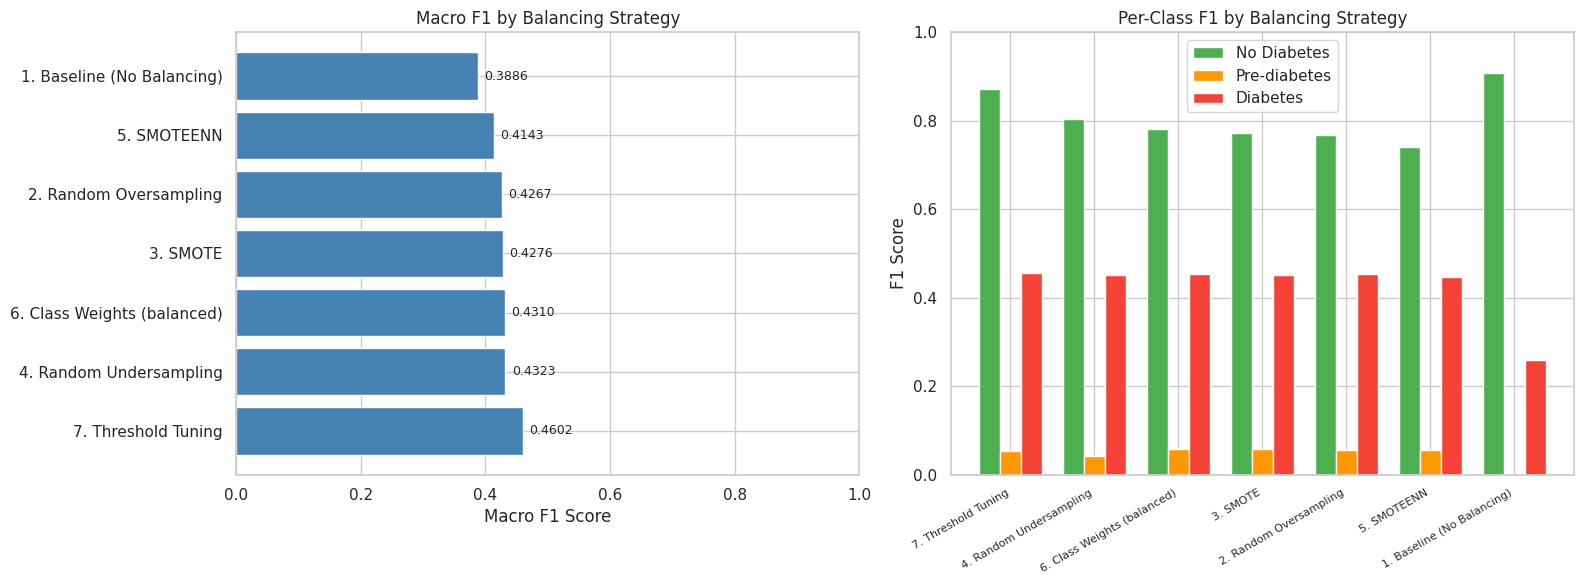

In [18]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Macro F1', ascending=False).reset_index(drop=True)

print('\n' + '='*70)
print('COMPARISON TABLE (sorted by Macro F1)')
print('='*70)
print(comparison_df.to_string(index=False))
print('\n>>> Best strategy:', comparison_df.iloc[0]['Strategy'])

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Macro F1
axes[0].barh(comparison_df['Strategy'], comparison_df['Macro F1'],
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Macro F1 Score')
axes[0].set_title('Macro F1 by Balancing Strategy')
axes[0].set_xlim(0, 1)
for i, v in enumerate(comparison_df['Macro F1']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=9)

# Per-class F1
x = range(len(comparison_df))
width = 0.25
axes[1].bar([i - width for i in x], comparison_df['F1 No-Diabetes'],
            width, label='No Diabetes', color='#4CAF50')
axes[1].bar(x, comparison_df['F1 Pre-diabetes'],
            width, label='Pre-diabetes', color='#FF9800')
axes[1].bar([i + width for i in x], comparison_df['F1 Diabetes'],
            width, label='Diabetes', color='#F44336')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(comparison_df['Strategy'], rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Per-Class F1 by Balancing Strategy')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


<h1>Neural Network</h1>

In [19]:
import os
import random
import numpy as np
import tensorflow as tf
import keras_tuner as kt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# TensorBoard logs base directory (each strategy gets its own subfolder)
TENSORBOARD_LOG_DIR = "tb_logs"
os.makedirs(TENSORBOARD_LOG_DIR, exist_ok=True)





def build_tabular_nn(hp):

    lr = hp.Choice(
        'learning_rate',
        values=[1e-2, 1e-3, 5e-4, 1e-4]
    )

    inputs = tf.keras.Input(shape=(X_train.shape[1],))

    x = tf.keras.layers.BatchNormalization()(inputs)

    x = tf.keras.layers.Dense(128, kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.3, seed=SEED)(x)

    x = tf.keras.layers.Dense(64, kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.25, seed=SEED)(x)

    x = tf.keras.layers.Dense(32, kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = tf.keras.layers.Dropout(0.2, seed=SEED)(x)

    outputs = tf.keras.layers.Dense(3, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def train_nn(X_tr, y_tr, X_val, y_val, X_test, y_test, label, class_weight=None):

    tuner = kt.RandomSearch(
        build_tabular_nn,
        objective="val_accuracy",
        max_trials=4,
        overwrite=True,
        directory="nn_tuning_" + label.replace(" ", "_"),  # ✅ prevent reuse
        project_name="run",
        seed=SEED
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    # TensorBoard callback (separate run folder per strategy)
    tb_run_dir = os.path.join(
        TENSORBOARD_LOG_DIR,
        label.replace(" ", "_").replace("/", "_")
    )
    tensorboard_cb = tf.keras.callbacks.TensorBoard(
        log_dir=tb_run_dir,
        histogram_freq=1,
        write_graph=True,
        update_freq='epoch'
    )

    tuner.search(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=80,
        batch_size=32,
        callbacks=[early_stop, tensorboard_cb],
        class_weight=class_weight,
        shuffle=True,   # ✅ VERY IMPORTANT (fixed)
        verbose=0
    )

    best_model = tuner.get_best_models(num_models=1)[0]

    y_pred = best_model.predict(X_test, verbose=0).argmax(axis=1)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    print("\n"+"="*60)
    print("NN -", label)
    print("="*60)

    print("Best Learning Rate:",
          tuner.get_best_hyperparameters(1)[0].get('learning_rate'))

    print("Accuracy:", round(acc,4))
    print("Macro F1:", round(macro_f1,4))

    print(classification_report(
        y_test, y_pred,
        target_names=['No Diabetes','Pre-diabetes','Diabetes']
    ))

    return {
        "Strategy": label,
        "Accuracy": round(acc,4),
        "Macro F1": round(macro_f1,4),
        # Keep the trained model so we can reuse it later (e.g., for confusion matrices)
        "Model": best_model
    }


# ==========================================================
# CLASS WEIGHTS
# ==========================================================

classes = np.array([0,1,2])

cw = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=np.asarray(y_train)
)

class_weight_dict = {i: w for i, w in zip(classes, cw)}



from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

ros = RandomOverSampler(random_state=SEED)
smote = SMOTE(random_state=SEED)
rus = RandomUnderSampler(random_state=SEED)
smoteenn = SMOTEENN(random_state=SEED)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
X_train_smoteenn, y_train_smoteenn = smoteenn.fit_resample(X_train, y_train)


nn_results = []

nn_results.append(train_nn(
    X_train, y_train, X_val, y_val, X_test, y_test,
    "1. Baseline (No Balancing)"
))

nn_results.append(train_nn(
    X_train_over, y_train_over, X_val, y_val, X_test, y_test,
    "2. Random Oversampling"
))

nn_results.append(train_nn(
    X_train_smote, y_train_smote, X_val, y_val, X_test, y_test,
    "3. SMOTE"
))

nn_results.append(train_nn(
    X_train_under, y_train_under, X_val, y_val, X_test, y_test,
    "4. Random Undersampling"
))

nn_results.append(train_nn(
    X_train_smoteenn, y_train_smoteenn, X_val, y_val, X_test, y_test,
    "5. SMOTEENN"
))

nn_results.append(train_nn(
    X_train, y_train, X_val, y_val, X_test, y_test,
    "6. Class Weights",
    class_weight=class_weight_dict
))

nn_df = pd.DataFrame(nn_results)\
          .sort_values("Macro F1", ascending=False)\
          .reset_index(drop=True)

print("\n"+"="*70)
print("NEURAL NETWORK COMPARISON (Fixed & Stable)")
print("="*70)

print(nn_df)

I0000 00:00:1773801450.092755    4242 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773801450.096554    4242 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773801450.492299    4242 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773801451.778878    4242 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


NN - 1. Baseline (No Balancing)
Best Learning Rate: 0.0001
Accuracy: 0.838
Macro F1: 0.3915
              precision    recall  f1-score   support

 No Diabetes       0.85      0.98      0.91     38012
Pre-diabetes       0.00      0.00      0.00       926
    Diabetes       0.61      0.17      0.26      7019

    accuracy                           0.84     45957
   macro avg       0.49      0.38      0.39     45957
weighted avg       0.79      0.84      0.79     45957



E0000 00:00:1773802421.557169    4242 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1773803334.762742    4242 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),


NN - 2. Random Oversampling
Best Learning Rate: 0.01
Accuracy: 0.6199
Macro F1: 0.4194
              precision    recall  f1-score   support

 No Diabetes       0.95      0.63      0.76     38012
Pre-diabetes       0.03      0.30      0.06       926
    Diabetes       0.35      0.61      0.44      7019

    accuracy                           0.62     45957
   macro avg       0.44      0.51      0.42     45957
weighted avg       0.84      0.62      0.69     45957



E0000 00:00:1773805332.887185    4242 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1773806065.379914    4242 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

...


NN - 4. Random Undersampling
Best Learning Rate: 0.0005
Accuracy: 0.6631
Macro F1: 0.4279
              precision    recall  f1-score   support

 No Diabetes       0.94      0.67      0.78     38012
Pre-diabetes       0.03      0.15      0.05       926
    Diabetes       0.34      0.67      0.45      7019

    accuracy                           0.66     45957
   macro avg       0.44      0.50      0.43     45957
weighted avg       0.83      0.66      0.72     45957



E0000 00:00:1773808548.824843    4242 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1773809276.072275    4242 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),


NN - 5. SMOTEENN
Best Learning Rate: 0.01
Accuracy: 0.5694
Macro F1: 0.4028
              precision    recall  f1-score   support

 No Diabetes       0.95      0.60      0.73     38012
Pre-diabetes       0.03      0.49      0.06       926
    Diabetes       0.40      0.43      0.42      7019

    accuracy                           0.57     45957
   macro avg       0.46      0.51      0.40     45957
weighted avg       0.85      0.57      0.67     45957



E0000 00:00:1773810709.893616    4242 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1773810838.550638    4242 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),


NN - 6. Class Weights
Best Learning Rate: 0.01
Accuracy: 0.652
Macro F1: 0.4243
              precision    recall  f1-score   support

 No Diabetes       0.95      0.65      0.77     38012
Pre-diabetes       0.02      0.12      0.04       926
    Diabetes       0.34      0.74      0.46      7019

    accuracy                           0.65     45957
   macro avg       0.44      0.50      0.42     45957
weighted avg       0.83      0.65      0.71     45957


NEURAL NETWORK COMPARISON (Fixed & Stable)
                     Strategy  Accuracy  Macro F1  \
0     4. Random Undersampling    0.6631    0.4279   
1            6. Class Weights    0.6520    0.4243   
2      2. Random Oversampling    0.6199    0.4194   
3                    3. SMOTE    0.6285    0.4186   
4                 5. SMOTEENN    0.5694    0.4028   
5  1. Baseline (No Balancing)    0.8380    0.3915   

                                      Model  
0  <Functional name=functional, built=True>  
1  <Functional name=functional

## Neural Network: Confusion Matrices (Test Set)

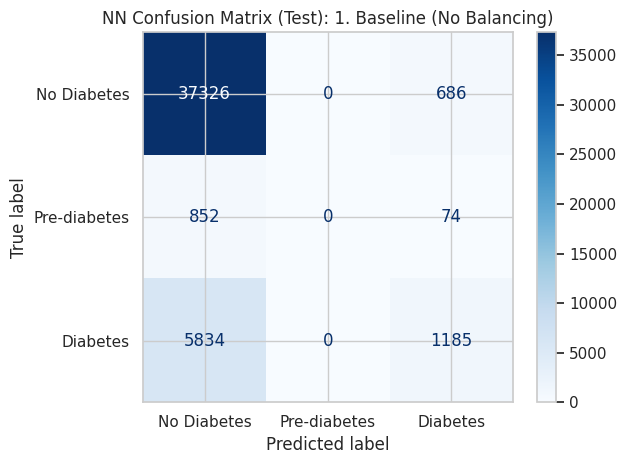

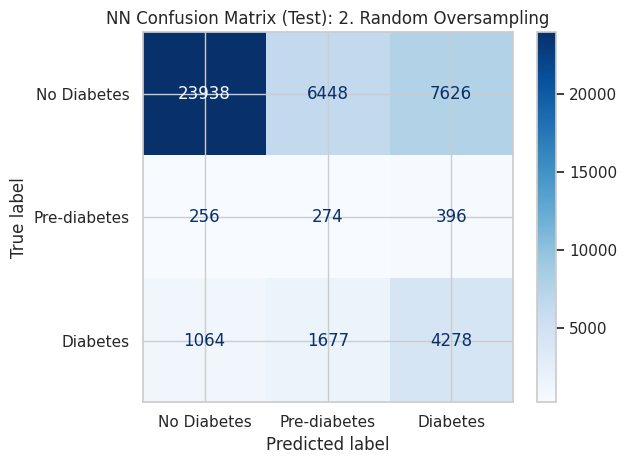

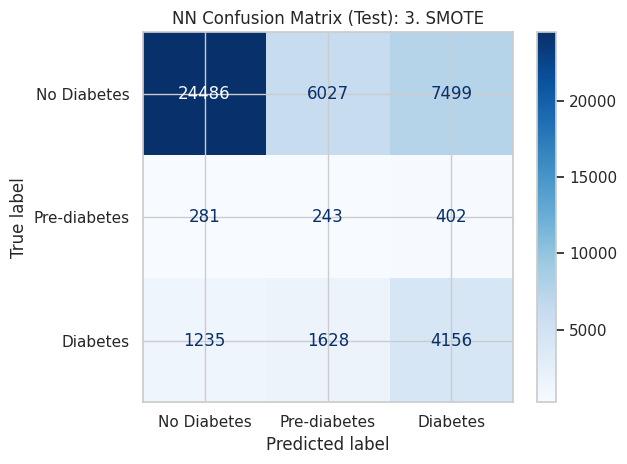

E0000 00:00:1773811622.335439    4242 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


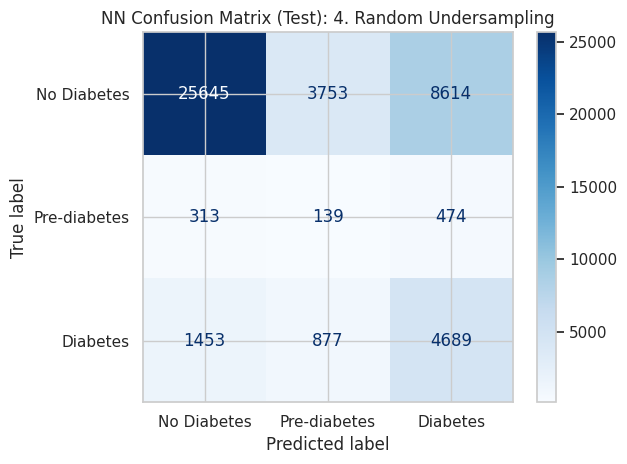

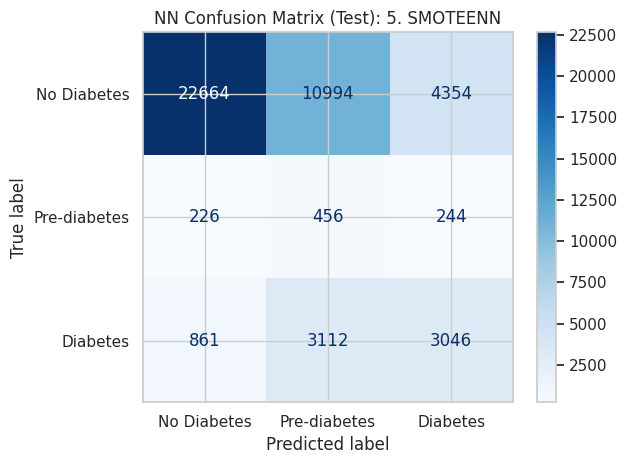

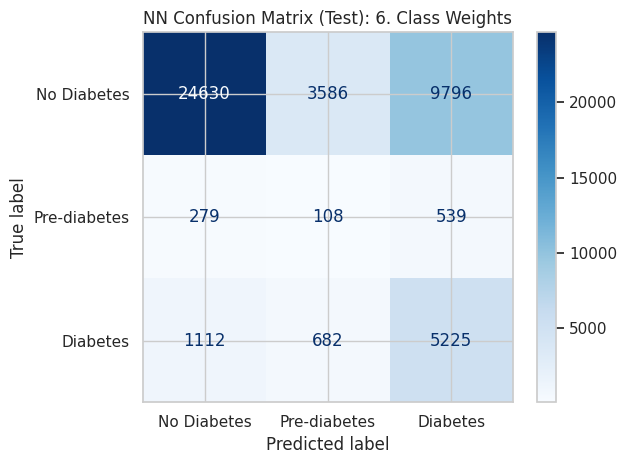

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

def plot_nn_confusion_matrices_from_trained(nn_results, X_test, y_test):
    """Reuse the already-trained NN models (stored in nn_results) to plot test confusion matrices."""
    for res in nn_results:
        label = res.get("Strategy", "NN")
        model = res.get("Model", None)
        if model is None:
            raise ValueError(
                f"No trained model found for strategy '{label}'. "
                "Make sure you ran the NN training cell above first."
            )
        y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            display_labels=['No Diabetes', 'Pre-diabetes', 'Diabetes'],
            cmap='Blues'
        )
        plt.title(f"NN Confusion Matrix (Test): {label}")
        plt.tight_layout()
        plt.show()


plot_nn_confusion_matrices_from_trained(nn_results, X_test, y_test)

<h1>KNN</h1>

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def tune_and_evaluate_knn(X_tr, y_tr, label):
    k_values = [3, 5, 11, 21]
    metrics = ['euclidean', 'manhattan']

    best_k, best_metric, best_val_f1 = None, None, 0

    # Hyperparameter Tuning on Validation Set
    for k in k_values:
        for m in metrics:
            knn = KNeighborsClassifier(n_neighbors=k, metric=m)
            knn.fit(X_tr, y_tr)

            val_f1 = f1_score(y_val, knn.predict(X_val), average='macro')

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_k = k
                best_metric = m

    print(f"\n{'='*40}\n{label}\n{'='*40}")
    print(f"Best Hyperparameters: k={best_k}, metric={best_metric}")

    # Final Training & Test Evaluation
    final_knn = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
    final_knn.fit(X_tr, y_tr)
    y_pred = final_knn.predict(X_test)

    # Metrics Evaluation
    acc = accuracy_score(y_test, y_pred)
    f1_micro = f1_score(y_test, y_pred, average='micro')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    print(f"Accuracy:    {acc:.4f}")
    print(f"Micro F1:    {f1_micro:.4f}")
    print(f"Macro F1:    {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['No Diabetes', 'Pre-diabetes', 'Diabetes'],
        cmap='Blues'
    )
    plt.title(f"Confusion Matrix: {label}")
    plt.show()


Baseline KNN (Imbalanced Data)
Best Hyperparameters: k=5, metric=manhattan
Accuracy:    0.8166
Micro F1:    0.8166
Macro F1:    0.3994
Weighted F1: 0.7870


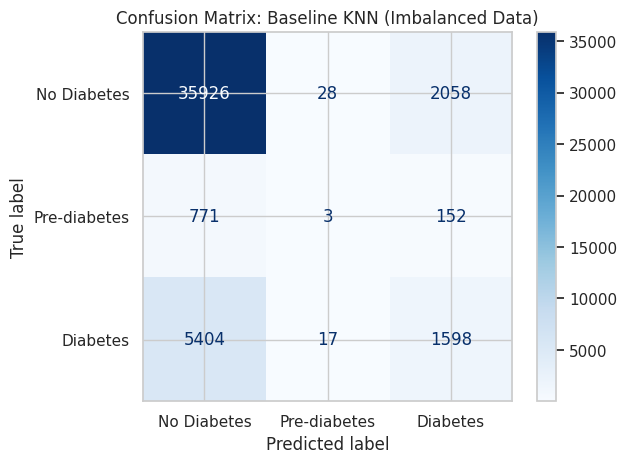


KNN with Random Oversampling
Best Hyperparameters: k=5, metric=euclidean
Accuracy:    0.7032
Micro F1:    0.7032
Macro F1:    0.4131
Weighted F1: 0.7347


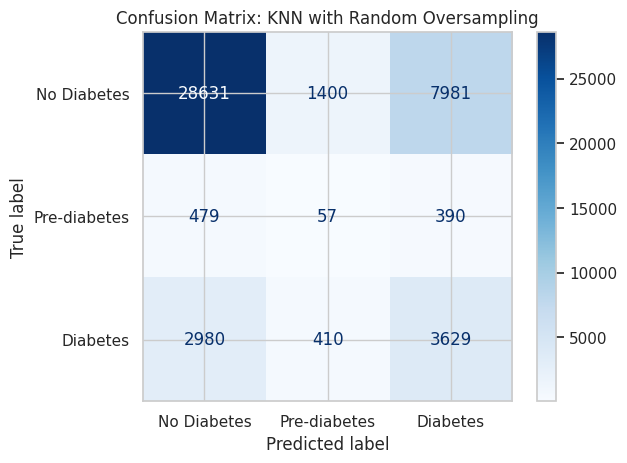


KNN with SMOTE
Best Hyperparameters: k=5, metric=manhattan
Accuracy:    0.7177
Micro F1:    0.7177
Macro F1:    0.4166
Weighted F1: 0.7453


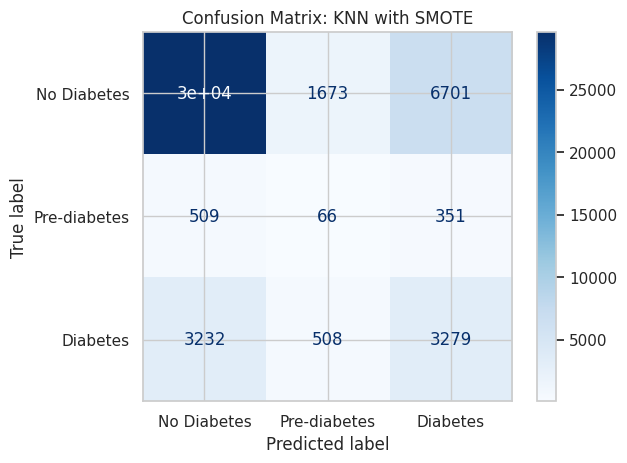


KNN with Random Undersampling
Best Hyperparameters: k=21, metric=manhattan
Accuracy:    0.5827
Micro F1:    0.5827
Macro F1:    0.3987
Weighted F1: 0.6693


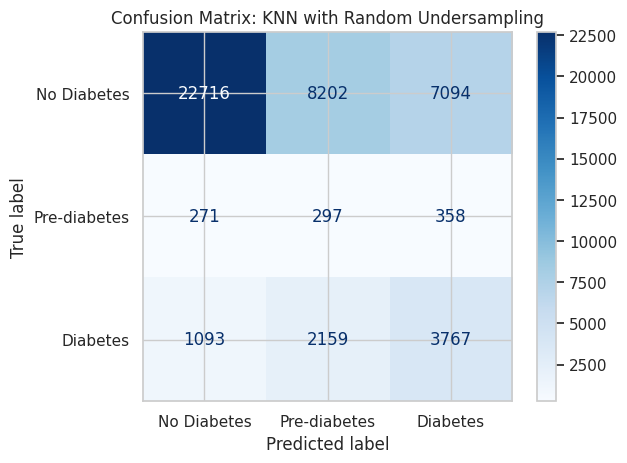

In [22]:
# 1. Baseline (Imbalanced)
tune_and_evaluate_knn(X_train, y_train, "Baseline KNN (Imbalanced Data)")

# 2. Random Oversampling
tune_and_evaluate_knn(X_train_over, y_train_over, "KNN with Random Oversampling")

# 3. SMOTE
tune_and_evaluate_knn(X_train_smote, y_train_smote, "KNN with SMOTE")

# 4. Random Undersampling
tune_and_evaluate_knn(X_train_under, y_train_under, "KNN with Random Undersampling")